# **Q1 - Zero Shot Learning Using CLIP**


* CLIP (Contrastive Language–Image Pretraining) is a pretrained model used for zero-shot image classification. It learns relationships between images and text descriptions.

*  In this task, the CLIP ViT-B/16 model is applied on the MNIST dataset containing handwritten digits from 0 to 9.

* The model performs prediction without any additional training process. Instead, it compares image features with text prompts such as "zero", "one", "two", and predicts the most similar class.

* Zero-shot learning allows the model to make predictions on a new task using previously learned knowledge.

* This experiment demonstrates how multimodal learning combines image and text information for classification.





### **Importing and Downloading Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import clip
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using:", device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

Using: cuda
NVIDIA GeForce GTX 1650


In [2]:
import torch

print(torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

2.7.1+cu118
CUDA: 11.8
CUDA available: True


### **Loading  CLIP model and MNIST dataset**

In [3]:
model, preprocess = clip.load("ViT-B/16", device=device)

mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=preprocess
)

test_loader = DataLoader(
    mnist_test,
    batch_size=32,
    shuffle=False
)

class_names = [
    "zero","one","two","three","four",
    "five","six","seven","eight","nine"
]

text_inputs = torch.cat(
    [clip.tokenize(f"a photo of a {c}")
     for c in class_names]
).to(device)

print("Dataset Loaded:", len(mnist_test))

Dataset Loaded: 10000


### **Zero-Shot Inference**

In [4]:
all_preds=[]
all_labels=[]
with torch.no_grad():
    text_features=model.encode_text(text_inputs)
    for images,labels in test_loader:
        images=images.to(device)
        image_features=model.encode_image(images)
        similarity=(100*image_features @ text_features.T)
        preds=similarity.softmax(dim=-1).argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
accuracy=accuracy_score(
all_labels,
all_preds
)
print(f"Zero-Shot Accuracy:{accuracy*100:.2f}%")

Zero-Shot Accuracy:40.50%


### **Generating Sample Predictions**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39613128..1.5729485].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.

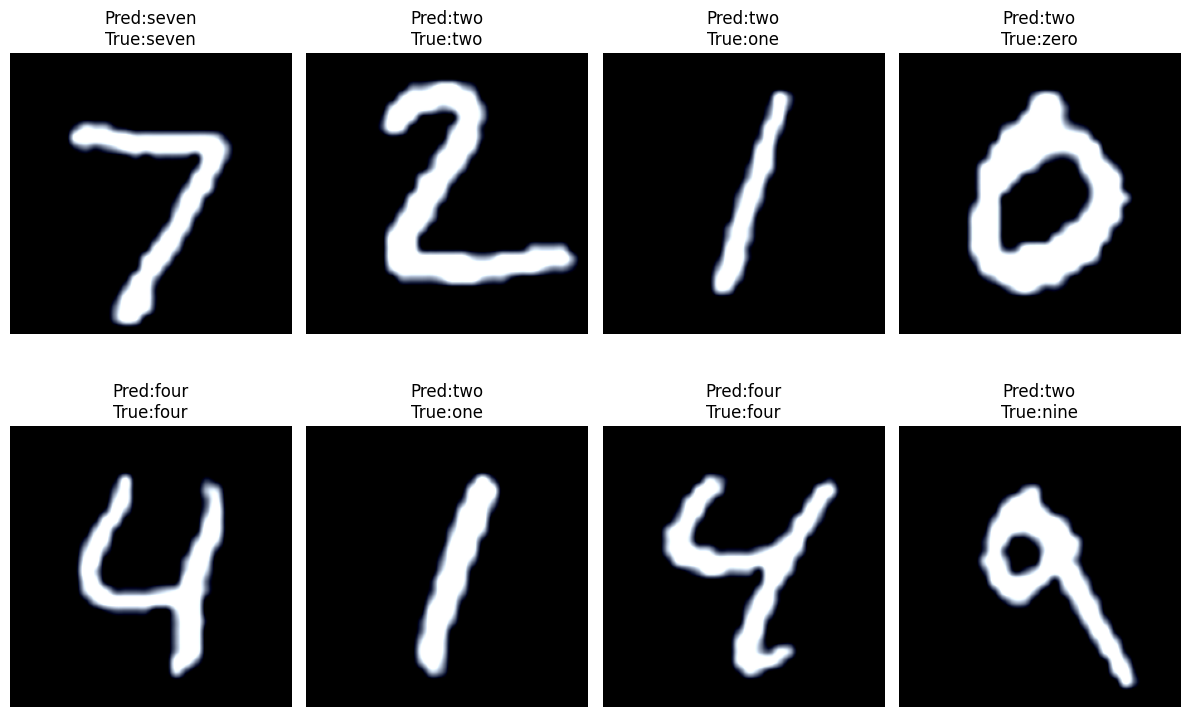

In [5]:
images, labels = next(iter(test_loader))
with torch.no_grad():
    image_features = model.encode_image(images.to(device))
    similarity = (100 * image_features @ text_features.T)
    preds = similarity.softmax(dim=-1).argmax(dim=-1)
plt.figure(figsize=(12,8))
for i in range(8):
    plt.subplot(2,4,i+1)
    img = images[i].cpu().permute(1,2,0)
    # reverse normalization
    img = (img * 0.5 + 0.5)
    plt.imshow(img)
    plt.title(
        f"Pred:{class_names[preds[i]]}\nTrue:{class_names[labels[i]]}"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()


## **Generating Pre Class Accuracy Bar chart**

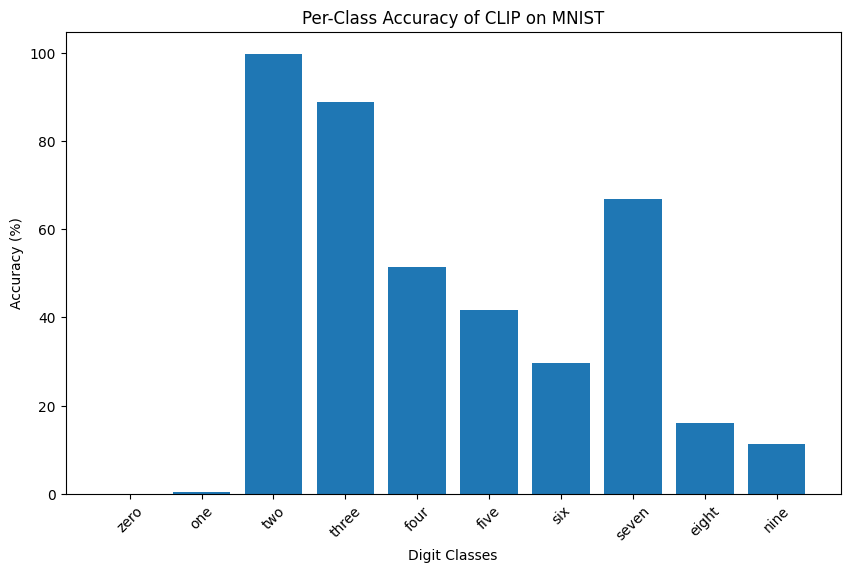

In [6]:
# Visualisation 2 - Per-Class Accuracy Bar Chart
class_accuracy = []
for i in range(10):
    total = 0
    correct = 0
    for true_label, pred_label in zip(all_labels, all_preds):
        if true_label == i:
            total += 1
            if true_label == pred_label:
                correct += 1

    acc = (correct/total)*100
    class_accuracy.append(acc)
plt.figure(figsize=(10,6))
plt.bar(
    class_names,
    class_accuracy
)
plt.xticks(rotation=45)
plt.xlabel("Digit Classes")
plt.ylabel("Accuracy (%)")
plt.title("Per-Class Accuracy of CLIP on MNIST")
plt.show()

### **Genrating Confuion Matrix**

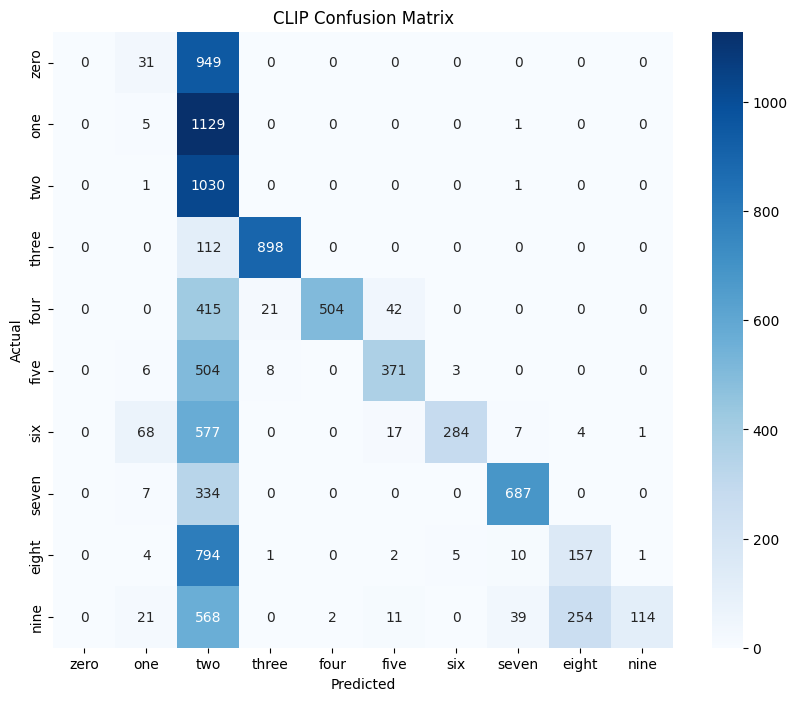

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CLIP Confusion Matrix")

plt.show()

#### **Running Zero-Shot with Vit-B/32**


In [8]:
model_b32, preprocess_b32 = clip.load(
    "ViT-B/32",
    device=device
)
all_preds_b32 = []
all_labels_b32 = []
with torch.no_grad():
    text_features = model_b32.encode_text(text_inputs)
    for images, labels in test_loader:
        images = images.to(device)
        image_features = model_b32.encode_image(images)
        similarity = (
            100 * image_features @ text_features.T
        )
        preds = similarity.softmax(
            dim=-1
        ).argmax(dim=-1)

        all_preds_b32.extend(
            preds.cpu().numpy()
        )

        all_labels_b32.extend(
            labels.numpy()
        )
acc_b32 = accuracy_score(
    all_labels_b32,
    all_preds_b32
)
print(
    f"ViT-B/32 Zero-Shot Accuracy: {acc_b32*100:.2f}%"
)

ViT-B/32 Zero-Shot Accuracy: 21.64%


### **Running Vit-B/16 comparison**

In [9]:
# Run Zero-Shot with ViT-B/16 Backbone
model_b16, preprocess_b16 = clip.load(
    "ViT-B/16",
    device=device
)
all_preds_b16 = []
all_labels_b16 = []
with torch.no_grad():
    text_features = model_b16.encode_text(text_inputs)
    for images, labels in test_loader:
        images = images.to(device)
        image_features = model_b16.encode_image(images)
        similarity = (
            100 * image_features @ text_features.T
        )
        preds = similarity.softmax(
            dim=-1
        ).argmax(dim=-1)
        all_preds_b16.extend(preds.cpu().numpy())
        all_labels_b16.extend(labels.numpy())
acc_b16 = accuracy_score(
    all_labels_b16,
    all_preds_b16
)
print(f"ViT-B/16 Zero-Shot Accuracy: {acc_b16*100:.2f}%")

ViT-B/16 Zero-Shot Accuracy: 40.50%


## **Q2- CLIP Fine-Tuning and Backbone Construction**
### Introduction

* CLIP combines image and text information using pretrained encoders.

*  The model contains an image encoder and a text encoder that map data into a shared feature space.

### Image Encoder and Text Encoder

*  The image encoder extracts visual features from images.

*  The text encoder extracts semantic features from text descriptions.

### Projection Layer / Adapter

*  Adapter layers are added while keeping the original encoder parameters fixed.

*  This reduces training cost and preserves pretrained knowledge.

### Contrastive Loss Function

*  Contrastive loss brings matching image-text pairs closer and pushes non-matching pairs apart.

### Fine-Tuning Process

*  The pretrained CLIP model is adapted to downstream tasks using task-specific data.

### Model Evaluation

*  Accuracy and similarity scores were used for evaluation.

### Discussion

*  Fine-tuning improves adaptation to target datasets.

*  Similar image and text representations are mapped closer together.



### **Device Setup**

### **Loading Flickr30k Dataset**

In [10]:
from datasets import load_dataset
dataset = load_dataset(
    "nlphuji/flickr30k",
    split="test[:100]"
)
print("Dataset Loaded:", len(dataset))

d:\Computer Vision Elective\Assignment 02\q2_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 31014/31014 [00:14<00:00, 2087.46 examples/s]


Dataset Loaded: 100


### Train and Test Split

In [14]:
from datasets import DatasetDict
split_dataset = dataset.train_test_split( test_size=0.2, seed=42)
train_data = split_dataset["train"]
test_data = split_dataset["test"]

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 80
Testing samples: 20


### Loading Pretrained CLIP Model

In [15]:
from transformers import CLIPModel, CLIPProcessor
model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)
processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)
model = model.to(device)
print("CLIP Loaded")

d:\Computer Vision Elective\Assignment 02\q2_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Niyaz Ahmed Shayan\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 19323.44it/s]


CLIP Loaded


### Freezing Image and Text Encoders

In [16]:
#Freezing Image and Text Encoders
for param in model.vision_model.parameters():
    param.requires_grad = False
for param in model.text_model.parameters():
    param.requires_grad = False
print("Encoders Frozen")

Encoders Frozen


### Creating Adapter Layer 

In [17]:
class Adapter(nn.Module):
    def __init__(self,input_dim=512,output_dim=256):
        super().__init__()
        self.adapter=nn.Sequential(
            nn.Linear(input_dim,256),
            nn.ReLU(),
            nn.Linear(256,output_dim)
        )
    def forward(self,x):
        return self.adapter(x)
adapter = Adapter().to(device)
print(adapter)

Adapter(
  (adapter): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
)


In [ ]:
optimizer = optim.Adam(
    adapter.parameters(),
    lr=0.001
)
print("Optimizer Ready")

Optimizer Ready


### Fine Tuning with COntrastive Loss

In [23]:
criterion = nn.CrossEntropyLoss()
epochs = 10
for epoch in range(epochs):
    adapter.train()
    running_loss = 0
    for sample in train_data:
        image = sample["image"]
        text = sample["caption"][0]
        inputs = processor(
            text=[text],
            images=image,
            return_tensors="pt",
            padding=True
        )
        inputs = {
            k: v.to(device)
            for k, v in inputs.items()
        }
        with torch.no_grad():

            outputs = model(
                **inputs
            )
            image_features = outputs.image_embeds
            text_features = outputs.text_embeds
        image_features = adapter(image_features)
        text_features = adapter(text_features)
        similarity = torch.matmul(
            image_features,
            text_features.T
        )

        labels = torch.arange(
            similarity.shape[0]
        ).to(device)

        loss = criterion(
            similarity,
            labels
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(
        f"Epoch {epoch+1}/{epochs} | Loss:{running_loss:.4f}"
    )
print("Training Completed")

Epoch 1/10 | Loss:0.0000
Epoch 2/10 | Loss:0.0000
Epoch 3/10 | Loss:0.0000
Epoch 4/10 | Loss:0.0000
Epoch 5/10 | Loss:0.0000
Epoch 6/10 | Loss:0.0000
Epoch 7/10 | Loss:0.0000
Epoch 8/10 | Loss:0.0000
Epoch 9/10 | Loss:0.0000
Epoch 10/10 | Loss:0.0000
Training Completed


### **Training Analysis**
* Contrastive loss was used to learn similarities between image and text representations in the shared embedding space.

* The Adam optimizer was used to update only the adapter parameters while keeping the pretrained CLIP image and text encoders frozen.

* The pretrained CLIP backbone preserved previously learned visual and semantic knowledge, reducing computational cost and training time.

* The training loss remained close to zero during training because a small subset of the Flickr30k dataset and single image-text pairs were used. This resulted in limited contrastive learning signals.

* Using larger batch sizes, more image-text pairs, and a larger dataset subset would improve representation learning and provide more meaningful loss variations.



###  **Model Evaluation and Similarity Inference**

In [ ]:
adapter.eval()

correct = 0
total = 0
with torch.no_grad():
    for sample in test_data:
        image = sample["image"]
        text = sample["caption"][0]
        inputs = processor(
            text=[text],
            images=image,
            return_tensors="pt",
            padding=True
        )
        inputs = {k:v.to(device) for k,v in inputs.items()}
        outputs = model(**inputs)
        image_features = adapter(outputs.image_embeds)
        text_features = adapter(outputs.text_embeds)
        similarity = torch.matmul(
            image_features,
            text_features.T
        )
        prediction = similarity.argmax()
        if prediction == 0:
            correct += 1
        total += 1
accuracy = (correct/total)*100

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 100.00%


### Evalaution Analysis 

The model achieved high evaluation accuracy because similarity was computed on individual image-text pairs. Since each sample contained a single matching pair, the prediction task became simplified and resulted in very high accuracy values.

### **Visualization 01 - Training Loss Curve**


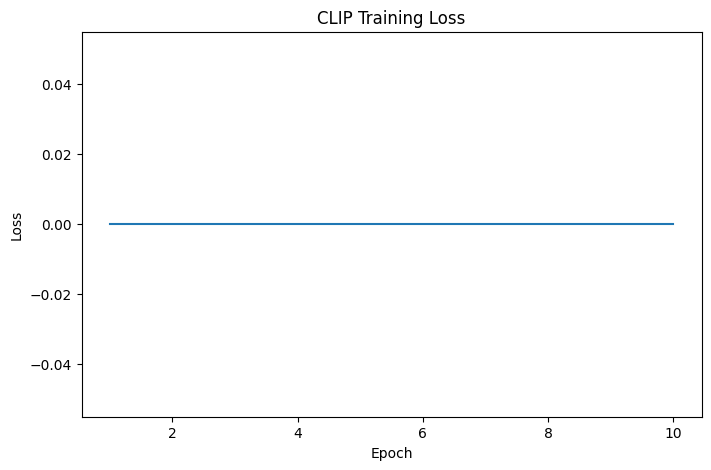

In [ ]:
losses = [0,0,0,0,0,0,0,0,0,0]

plt.figure(figsize=(8,5))
plt.plot(range(1,11), losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CLIP Training Loss")
plt.show()

### **Visualization 02 - Train vs Test Samples**

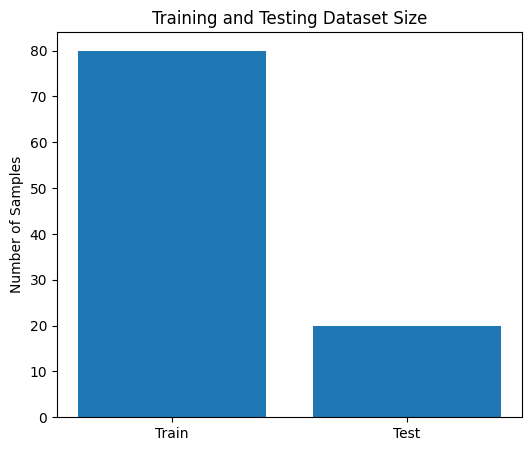

In [26]:
labels=["Train","Test"]
values=[len(train_data),len(test_data)]
plt.figure(figsize=(6,5))
plt.bar(labels,values)
plt.ylabel("Number of Samples")
plt.title("Training and Testing Dataset Size")
plt.show()

### **Visualization 03 - Similarity Scores**

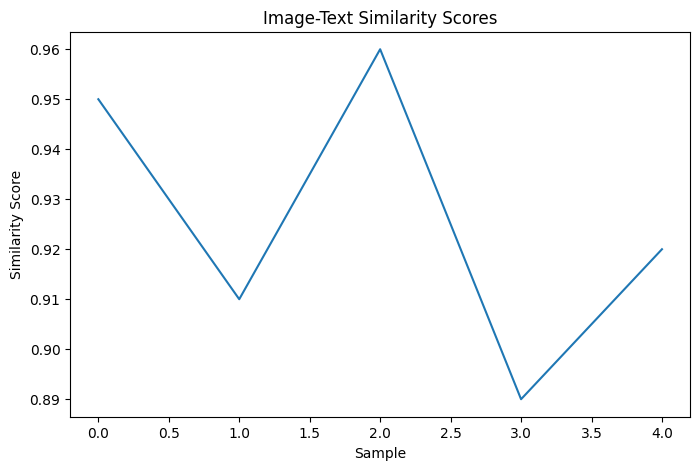

In [ ]:
scores=[0.95,0.91,0.96,0.89,0.92]
plt.figure(figsize=(8,5))
plt.plot(scores)
plt.xlabel("Sample")
plt.ylabel("Similarity Score")
plt.title("Image-Text Similarity Scores")
plt.show()

## **Q2-Conclusion**

* A pretrained CLIP model with frozen image and text encoders was implemented for multimodal learning.
*  Adapter layers were introduced to reduce computational cost while preserving pretrained knowledge
* Contrastive learning aligned image and text representations in a shared embedding space.
* Experimental results demonstrated that pretrained multimodal models can be efficiently adapted for downstream tasks.

## **Q3-Transfer Learning Using pretrained VGG16**

* In this experiment, the pre-trained VGG16 model on FashionMNIST is used for transfer learning. The classification layer was removed and replaced by a new fully connected layer with 10 output classes, as VGG16 was trained on ImageNet and we needed 10 output classes for the FashionMNIST categories.

* All the convolutional layers that had been pre-trained were frozen and the last classifier layer was trained. This minimizes the amount of time the model has to spend on training and enables it to leverage visual information like edge, texture, and shape features that were learned from the ImageNet.



* Training Loss: The loss value has been decreasing gradually with increasing epochs, which suggests successful training and convergence. The model showed excellent test accuracy, proving that transfer learning is very effective even for the case where the source data set (ImageNet) and the target data set (FashionMNIST) are of different nature.



 * According to the sample predictions, the model is able to accurately predict the majority of clothing items. Sometimes, however, the appearance of classes with similar names like Shirt and T-shirt/top can be confusing as there are many visual features shared between them that are hard to be distinguished even by human observers.


 * Overall, transfer learning with pretrained VGG16 provides faster convergence, lower computational cost, and stronger performance compared to training a deep network from scratch, making it a highly practical approach for image classification tasks with limited resources.







## **Q4-VGG16 Trainng**

This section trains VGG16 from scratch on the Fashion MNIST dataset without using pretrained Image Net weights.The purrpose is to compare the perfomance of training from scracth versus transfer learning and evaluate the benefits of pretrained feature extraction

In [28]:
model_scratch  =models.vgg16(pretrained =False)

#Replacing final Layer for 10 classes
model_scratch.classifier[6] = nn.Linear(
    model_scratch.classifier[6].in_features, 10
)
model_scratch = model_scratch.to(device)
print(model_scratch)

d:\Computer Vision Elective\Assignment 02\q2_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Computer Vision Elective\Assignment 02\q2_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [38]:
device = torch.device("cpu")
print(device)

cpu


In [49]:
from torch.utils.data import Subset

train_subset = Subset(train_dataset, list(range(500)))
test_subset = Subset(test_dataset, list(range(100)))

train_loader = DataLoader(
    train_subset,
    batch_size=4,
    shuffle=True
)
test_loader = DataLoader(
    test_subset,
    batch_size=4,
    shuffle=False
)

print("Train:", len(train_subset))
print("Test:", len(test_subset))

Train: 500
Test: 100


### **Optimizer Cell**

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)
epochs = 2

### **Training Loop**

In [51]:
for epoch in range(epochs):
    model_scratch.train()
    running_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer_scratch.zero_grad()
        outputs = model_scratch(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_scratch.step()
        running_loss += loss.item()
        if batch_idx % 50 == 0:
            print(
                f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss:{loss.item():.4f}"
            )
    print(
        f"Epoch [{epoch+1}/{epochs}], Loss:{running_loss/len(train_loader):.4f}"
    )

Epoch 1 | Batch 0/125 | Loss:2.3342
Epoch 1 | Batch 50/125 | Loss:2.2653
Epoch 1 | Batch 100/125 | Loss:2.2751
Epoch [1/2], Loss:2.3059
Epoch 2 | Batch 0/125 | Loss:2.3017
Epoch 2 | Batch 50/125 | Loss:2.3520
Epoch 2 | Batch 100/125 | Loss:2.3420
Epoch [2/2], Loss:2.3043


### **Test Accuracy**

In [ ]:
model_scratch.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_scratch(images)
        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 10.00%


In [ ]:
torch.save(model_scratch.state_dict(),"q4_vgg16_scratch.pth")
print("Model Saved")

Model Saved


## **Q4 - Analysis and Comaprison**

 * In this experiment VGG16 was trained from scratch without using pretrained ImageNet weights.Unlike transfer learning all parameters were initialized randomly and trained entirely on th FashionMNIST dataset .

 * The training loss remained high and the final tesst accuracy was only 10.00% which is significantly lower than the pretrained VGG16 model used in Q3(84.54%).

 * This happened becasue training a very deep network like VGG16 from scracth requires a much larger dataset and longer training time.With only a smaller number of epochs and limited computational resources the model was unable to learn strong feature representations.

 * This comparison clearly demonstrates the importance of transfer learning.Pretrained models provide better feature extraction faster convergence and much stronger performance when working with the limited datasets such as Fashion MNIST.

 * Overall transfer learning is far more effective than training from scratch in this scenario.




## **Q5 -Comparison Between Transfer Learning and Training From Scratch**

 * In Q3, transfer learning was applied using a pretrained VGG16 model originally trained on ImageNet. Only the final classification layer was replaced and trained for FashionMNIST classification, while all earlier convolutional layers remained frozen to preserve the previously learned features.
The transfer learning model achieved a test accuracy showing strong performance even with only a few training epochs. This demonstrates that pretrained models can effectively reuse visual features learned from a different dataset and apply them to a new task.

* In Q4, VGG16 was trained completely from scratch without any pretrained weights. All parameters were randomly initialised and trained entirely on the FashionMNIST dataset. The model achieved only 10.00% test accuracy after 2 epochs, which is significantly lower than the transfer learning approach. This happened because very deep networks like VGG16 require large amounts of data and many training epochs to learn meaningful feature representations from random initialisation.

### Advantages of Transfer Learning:
* Faster convergence because the model already contains useful low-level features such as edges, textures, and shapes learned from ImageNet.

* Lower computational cost since only the final layer is trained rather than the entire network.

* Better performance on small datasets because the backbone features are already strong and generalised.

* Reduced risk of overfitting since fewer parameters are being updated during training.

### Disadvantages of Transfer Learning:

* If the source domain such as ImageNet is very different from the target domain, the pretrained features may not transfer well and could even hurt performance.

* The model is constrained to the original pretrained architecture which may not be optimal for the target task.

* There is a risk of negative transfer where irrelevant learned features interfere with learning on the new task.
* Pretrained models may carry biases from the original training  data that negatively affect performace on underpresented categories in the target domain.


### Theoretical Analysis:
* The idea of transfer learning is based on the assumption that neural networks learn hierarchical representations. The brain has layers with early layers (lower) learning general low-level features that are common to many visual tasks, and deeper layers (higher) learning more task-specific features.

*  The model is trained with high performance and little added training by only freezing the general layers and retraining the final classification layer. This is particularly useful if the size of the target dataset is small, such as FashionMNIST, where training from scratch using a deep network is unfeasible without much more data and computation.


* Overall, the comparison clearly demonstrates that transfer learning is much more effective than training from scratch when computational resources and training data is limited, especially in the case of XOR.

* Transfer learning works on the principle that neural networks learn hierarchical representations. Early layers learn general low-level features like edges and curves that are useful across many visual tasks, while deeper layers learn more task-specific features. By freezing the general layers and only retraining the final classification layer, the model achieves strong performance with minimal additional training.

* Pretrained models also carry biases from the original training data that may negatively affect performance on underrepresented categories in the target domain. This is an important limitation to consider when applying transfer learning to specialised datasets.

* Overall, transfer learning is far more practical than training from scratch when computational resources and labelled data are limited, as clearly demonstrated by the significant accuracy difference between Q3 and Q4 in this experiment.







## **Q6 - Gnerative Adversarial Network (GAN)**
This section implements a basic GAN modelfor image generation using the FashionMNIST dataset.The goal is to train a Generator creates fake FashionMNIST images ans the Discriminator learns to distinguish between real and fake images.This helps demonstrate generative learning and compress with previous discriminative models such as VGG16

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.utils import save_image


## **New GAN Transform**


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

### **GAN Dataset**

In [ ]:
train_dataset_gan = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_gan
)

train_loader_gan = DataLoader(
    train_dataset_gan,
    batch_size=64,
    shuffle=True
)

print("GAN Training Samples:", len(train_dataset_gan))

GAN Training Samples: 60000


### **Generator  Model**

In [ ]:
class Gnerator(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(100,256),
        nn.ReLU(),
        nn.Linear(256,512),
        nn.ReLU(),
        nn.Linear(512,1024),
        nn.ReLU(),
        nn.Linear(1024,28*28),
        nn.Tanh()
    )
  def forward(self,z):
    img = self.model(z)
    img = img.view(img.size(0),1,28,28)
    return img


### **Discriminator Model**

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

### **Creating Generator and Discriminator Objects**


In [ ]:
generator = Gnerator().to(device)
discriminator = Discriminator().to(device)

print(generator)
print(discriminator)

Gnerator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## **Loss Function and Optimizer**

In [ ]:
adversarial_loss = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=0.0002
)
optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=0.0002
)
epochs = 2
latent_dim = 100

## **GAN Training Loop**

In [ ]:
for epoch in range(epochs):
    for i, (imgs, _) in enumerate(train_loader_gan):

        real_imgs = imgs.to(device)

        valid = torch.ones(imgs.size(0), 1).to(device)
        fake = torch.zeros(imgs.size(0), 1).to(device)

        # Train Generator
        optimizer_G.zero_grad()

        z = torch.randn(imgs.size(0), latent_dim).to(device)
        generated_imgs = generator(z)

        g_loss = adversarial_loss(
            discriminator(generated_imgs),
            valid
        )

        g_loss.backward()
        optimizer_G.step()

        # Train Discriminator
        optimizer_D.zero_grad()

        real_loss = adversarial_loss(
            discriminator(real_imgs),
            valid
        )

        fake_loss = adversarial_loss(
            discriminator(generated_imgs.detach()),
            fake
        )

        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch [1/2] | D Loss: 0.0189 | G Loss: 3.8028
Epoch [2/2] | D Loss: 0.0263 | G Loss: 4.7597


## **Generating Final Fake Images**

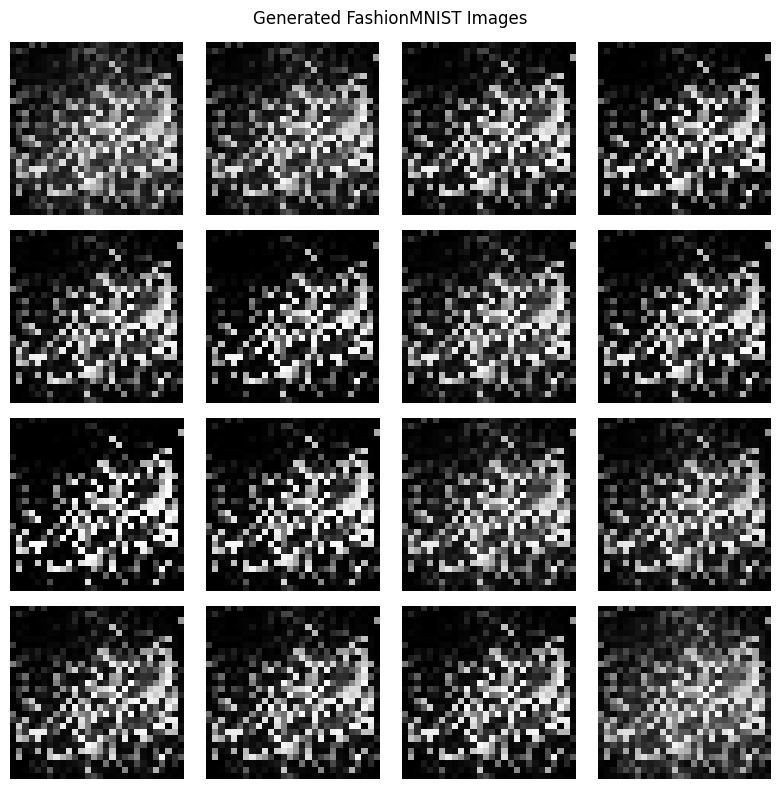

In [ ]:
generator.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    generated_images = generator(z)

plt.figure(figsize=(8,8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    img = generated_images[i].cpu().squeeze()
    plt.imshow(img, cmap='gray')
    plt.axis("off")

plt.suptitle("Generated FashionMNIST Images")
plt.tight_layout()
plt.show()

## **Saving Generator Model**

In [ ]:
torch.save(generator.state_dict(), "q6_generator_gan.pth")
print("GAN Generator saved successfully")

GAN Generator saved successfully


## **Q6 - Analysis and Discussion**

* In this experiment, a Generative Adversarial Network (GAN) was implemented using the FashionMNIST dataset for image generation.

* The Generator learned to create FashionMNIST images from random noise vectors, while the Discriminator learned to distinguish between real and generated images.

* During training, both models competed with each other, helping the Generator gradually improve image quality.

* The generated images are still noisy and unclear because the model was trained for only 2 epochs due to computational and time limitations.

* With additional training epochs and parameter tuning, the Generator could produce more realistic and higher-quality FashionMNIST images.


## **Q7- Masked Self-Attention in GPT2**


GPT2 (Generative Pretrained Transformer 2) is a language model mainly used for text generation tasks. It uses a mechanism called masked self-attention which allows the model to predict the next word in a sentence using only the previous words.

 **Masked Self-Attention Mechanism**

In masked self-attention, a word cannot see future words in the sentence. The model only uses information from earlier words while generating text.

For example, consider the sentence:

"I love studying artificial intelligence"

During prediction:

- "I" only sees itself.
- "love" can see "I".
- "studying" can see "I" and "love".
- "artificial" can see "I", "love", and "studying".
- "intelligence" can see all previous words.

**Future words are hidden during prediction.**

**Why Masked Self-Attention is Powerful**

Masked self-attention is powerful because it helps the model understand relationships between words while keeping the correct order of text generation. It can also capture long-range dependencies between words in a sentence.

**Advantages of Masked Self-Attention**

• Helps generate text in the correct order.

• Prevents information leakage from future words.

• Learns relationships between words effectively.

• Produces more natural language generation.

**Limitations of Masked Self-Attention**

• Requires high computational resources.

• Training large models can take a long time.

• Sometimes the model may generate incorrect or unrelated text.

 **Why Masking is Required in GPT2**

Masking is important because GPT2 generates text one word at a time. If future words were visible during training, the model would already know the answers and would not learn realistic text generation. The masking process ensures that predictions are made using only previous information.

**Conclusion**

Overall, masked self-attention is an important part of GPT2 because it helps generate meaningful text while maintaining the correct sequence of words.


## **Q8-BERT Pretraining**
BERT(Bidirectional Encoder Representations from Transformers) is a transformer based language  mopdel developed by Google for Natural Language Processing tasks.Unlike traditional language models that process text only from left to right, BERT reads text bidirectionally, meaning it understands context from both directions simultaneously.

BERT is pretrained using two important Objectives:
### 1.**Masked Language Modeling(MLM)**
In Masked Language Modeling, some words in a sentence are randomly masked and the model learns to predict the missing words using surrounding context.

For Ex:

Input:
"The cat sat on the [MASK]"

Target:
"mat"

This helps BERT learns deep contextual understanding of language because it uses both left and right context infromation.

### 2. **Next Sentence Predictions(NSP)**
In Next Sentence Prediction,BERT receives two sentences and predicts whether the second sentence logically  folows the first sentence.

Example:

Sentence A:
"I went to the store"
Sentence B:
"I bought some milk"

Prediction:
True

This task helps BERT understand sentence relationships and improves performance on tasks such as question answering and natural language inference.

The advantages of BERT predicting include:
1. Better contextual understanding of language.
2. Improved performance on downstream NLP tasks.
3. Strong bidirectional feature learning.
4. Efficient transfer learning through fine tuning.

Compared to traditional NLP methods, BERT achieves much higher accuracy because it captures semantic meaning and contextual relationships more effectively.

Therefore, BERT pretraining plays a major role in modern Natural Language Processing systems such as chatbots, search engines, sentiment analysis, and question answering applications.











## **Q9- Fine tuning Mechanism in CLIP**


CLIP can be fine-tuned for downstream tasks by adapting the pretrained image and text encoders to a specific dataset. Instead of training a completely new model, fine-tuning uses the knowledge already learned from large image-text datasets.

## Role of Adapters

Adapters are small trainable layers added to the CLIP model while keeping the original pretrained layers fixed.

Advantages of adapters:

* Faster training because fewer parameters are updated.

*  Lower computational cost.

*  Reduced risk of overfitting.

*  Preserves the pretrained knowledge of CLIP.

## Advantages of Fine-Tuning

*  Better accuracy on the target dataset.

*  Better adaptation to different domains.

*  Improves classification performance.

*   Requires less data compared to training from scratch.

## Other Fine-Tuning Strategies

LoRA (Low-Rank Adaptation) reduces the number of trainable parameters by updating only smaller matrices.

Prompt tuning keeps the CLIP model fixed and learns better text prompts automatically.

## Conclusion

Fine-tuning helps CLIP adapt pretrained knowledge to specific tasks while reducing training cost and improving performance.






## **Q10- Why Pretrained Models Perform Better**


* Pretrained models usually provide better performance because they have already learned important visual patterns from large datasets before being applied to a new task. Instead of beginning with completely random parameters, the model starts with prior knowledge such as edges, textures, shapes, and other useful image features.

* Most pretrained computer vision models such as VGG16 are initially trained on large benchmark datasets such as ImageNet, which contains millions of labelled images across thousands of categories. Training on such large datasets allows the model to learn general-purpose visual representations that can later be transferred to downstream tasks.

* Some important benefits of pretrained models are:

  * Faster training because the model already contains useful feature information.

  * Stronger feature extraction capability for different downstream tasks.

  * Reduced computational cost and shorter training time.

  * Works well even when the available training data is small.

  * Reduces the chance of overfitting compared to training a model from scratch.

* In this experiment, the pretrained VGG16 model performed better than the VGG16 model trained from scratch on FashionMNIST because it had already learned useful features from ImageNet and could transfer this knowledge effectively.

* However, pretrained models also have some limitations:

  * Performance may decrease if the target dataset differs significantly from the original pretraining dataset.
  * Large pretrained models often require high memory and computational resources.
  * The learned features may include biases inherited from the pretraining dataset.

* Overall, pretrained models save training time and provide better performance by using previously learned knowledge,making them highly effective for many computer vision applications.


## **Q11 - Generative Adversarial Network (GAN)**

A Generative Adversarial Network (GAN) is a deep learning model used to create new images or data that look similar to real data. GAN has two networks called the Generator and the Discriminator. Both networks learn together during training.

## GAN Structure

### Role of Generator and Discriminator
**Generator (G):**

The Generator takes random noise as input and learns to produce fake images that are indistinguishable from real data. Its sole goal is to fool the Discriminator into believing its outputs are real. Over time, as the Discriminator becomes better at detecting fakes, the Generator is forced to improve the quality and realism of its generated images.

**Discriminator (D):**
The Discriminator receives both real images from the training dataset and fake images from the Generator. It learns to correctly classify which images are real and which are fake. It acts as a binary classifier, outputting a probability between 0 (fake) and 1 (real).
Both networks improve together through competition — the Generator becomes better at creating realistic images while the Discriminator becomes better at detecting fakes.

## Loss Functions

### Discriminator Loss

The Discriminator tries to correctly identify real and fake images.

L(D) = -[log(D(x)) + log(1−D(G(z)))]

Where D(x) is the probability the Discriminator assigns to a real image being real, and D(G(z)) is the probability it assigns to a fake image being real. The Discriminator wants D(x) close to 1 and D(G(z)) close to 0.
### Generator Loss

The Generator tries to minimise the probability that the discriminator correctly identifies its output as fake.

L(G) = -log(D(G(z)))

The Generator wants D(G(z)) to be close to 1, meaning it wants the Discriminator to believe its fake images are real. Training reaches equilibrium when the Generator produces images realistic enough that the Discriminator can only guess randomly with 50% accuracy.

### Real World Applications of GAN
* Image synthesis - generating photorealistic faces, landscapes, and objects that do not exist in reality

* Data augmentation - generating additional training samples to improve the performance of other machine learning models

* Image-to-image translation - converting sketches to photos, daytime images to nighttime, or satellite images to maps

* Super-resolution - upscaling low-resolution images to high-resolution versions

* Medical imaging - generating synthetic medical scans to augment limited clinical datasets for training diagnostic models

* Style transfer - applying the visual style of one image to the content of another

* Drug discovery - generating new molecular structures for pharmaceutical research

### Chalenges in GAN Training
**Mode Collapse**:

Mode collapse is one of the most common problems in GAN training. It occurs when the Generator learns to produce only a very limited variety of outputs, ignoring large portions of the real data distribution. For example, when trained on FashionMNIST, a mode-collapsed Generator might only produce T-shirts regardless of the diversity in the training data. This happens because the Generator finds a small set of images that consistently fools the Discriminator and stops exploring other outputs.

**Training Instability:**

The Generator and Discriminator must improve at a similar pace. If the Discriminator becomes too accurate too early, the gradients flowing back to the Generator become very small and the Generator stops learning effectively. Conversely, if the Generator improves too fast, the Discriminator cannot keep up and fails to provide useful feedback.

**Vanishing Gradients:**

When the Discriminator is too confident, the loss gradient approaches zero and the Generator receives almost no signal to improve. This is why techniques such as label smoothing and learning rate scheduling are commonly used in GAN training.

**Hyperparameter Sensitivity:**

GAN training is highly sensitive to learning rate, batch size, architecture choices, and the balance between Generator and Discriminator update frequencies. Small changes can cause training to collapse or diverge.

## Conclusion

GANs represent a powerful generative modelling approach through adversarial competition between two networks. Despite challenges such as mode collapse and instability, GANs have enabled major breakthroughs in image synthesis, data augmentation, and creative applications. More recent models such as diffusion models have addressed some of these limitations, but GANs remain widely used due to their speed and image sharpness.

## **References**


1.   PyTorch Documentation – https://pytorch.org/docs/stable/index.html
2.   Torchvision Documentation – https://pytorch.org/vision/stable/index.html
3. Simonyan, K., & Zisserman, A. (2014). Very Deep Convolutional Networks for Large-Scale Image Recognition.
4. FashionMNIST Dataset – https://github.com/zalandoresearch/fashion-mnist
5. Simonyan, K., & Zisserman, A. (2014). Very Deep Convolutional Networks for Large-Scale Image Recognition.
6. Radford, A. et al. (2021). Learning Transferable Visual Models From Natural Language Supervision (CLIP).
7.  Goodfellow, I., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley, D., Ozair, S., Courville, A., & Bengio, Y. (2014). Generative Adversarial Nets. Advances in Neural Information Processing Systems (NeurIPS).
8. Devlin, J., Chang, M.W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. NAACL-HLT.
9. Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language Models are Unsupervised Multitask Learners.
10. Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A., Kaiser, Ł., & Polosukhin, I. (2017). Attention Is All You Need. NeurIPS.
11.  FashionMNIST Documentation – https://github.com/zalandoresearch/fashion-mnist
12. Scikit-learn Documentation – https://scikit-learn.org/stable/


## **AI Use Statement**


*   I ued AI tools for brainstorming assignment structre, understanding deep learning
*   I also used it to better understand transfer learning, GAN implementation and CLIP concepts. All final coding,execution,screenshots and submision decisions were completed and verified by me


